# CIFAR-10 Image Classification

This notebook trains and compares multiple deep learning models on CIFAR-10:
- **MLP**: Simple multi-layer perceptron
- **CNN**: Custom convolutional neural network
- **ResNet18**: Transfer learning with pretrained model

We use a subset of data for faster training and experimentation.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, recall_score

## Setup and Imports

Import all required libraries for deep learning and visualization.

In [3]:
# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Device Configuration

Check if GPU is available for faster training.

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Data augmentation for training - helps prevent overfitting
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),  # Randomly flip images
    transforms.RandomCrop(32, padding=4),     # Random crop with padding
    transforms.RandomRotation(15),            # Slight rotation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Color variations
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])  # CIFAR-10 stats
])

# No augmentation for validation - just normalize
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])
])

# Load full training dataset
train_dataset_full = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

val_dataset_full = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=val_transform
)

# Split into 80% train, 20% validation
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

# SUBSET FOR FASTER TRAINING: Use only 20% of data
subset_ratio = 0.2
train_subset_size = int(train_size * subset_ratio)
val_subset_size = int(val_size * subset_ratio)

print(f"Original train size: {train_size}, Using: {train_subset_size}")
print(f"Original val size: {val_size}, Using: {val_subset_size}")

# Create indices for subset
indices = list(range(len(train_dataset_full)))
train_indices = indices[:train_subset_size]
val_indices = indices[train_size:train_size + val_subset_size]

# Create subset datasets
from torch.utils.data import Subset
train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(val_dataset_full, val_indices)

# Create data loaders with subset
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

100%|██████████| 170M/170M [00:12<00:00, 13.7MB/s] 


Original train size: 40000, Using: 8000
Original val size: 10000, Using: 2000
Train batches: 63, Val batches: 16


## Data Loading and Preprocessing

Load CIFAR-10 dataset with augmentations for training and standard transforms for validation.

**Using subset of data for faster training!**

In [5]:
# ResNet requires 224x224 images with ImageNet normalization
train_transform_resnet = transforms.Compose([
    transforms.Resize((224,224)),             # Resize to ResNet input size
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

val_transform_resnet = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets for ResNet
train_dataset_resnet = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform_resnet
)

val_dataset_resnet = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=val_transform_resnet
)

In [6]:
# Use same subset split for ResNet data
train_indices_resnet = list(range(train_subset_size))
val_indices_resnet = list(range(train_size, train_size + val_subset_size))

train_resnet = Subset(train_dataset_resnet, train_indices_resnet)
val_resnet = Subset(val_dataset_resnet, val_indices_resnet)

print(f"ResNet train samples: {len(train_resnet)}, val samples: {len(val_resnet)}")

ResNet train samples: 8000, val samples: 2000


In [7]:
# DataLoaders for ResNet with smaller batch size (memory heavy)
train_loader_resnet = DataLoader(train_resnet, batch_size=64, shuffle=True)
val_loader_resnet = DataLoader(val_resnet, batch_size=64)

### Visualize Sample Images

Quick look at what our data looks like after augmentation.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0459638].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..0.91656935].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.9010187].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9577202..1.2013928].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8783362..0.6931434].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.98947

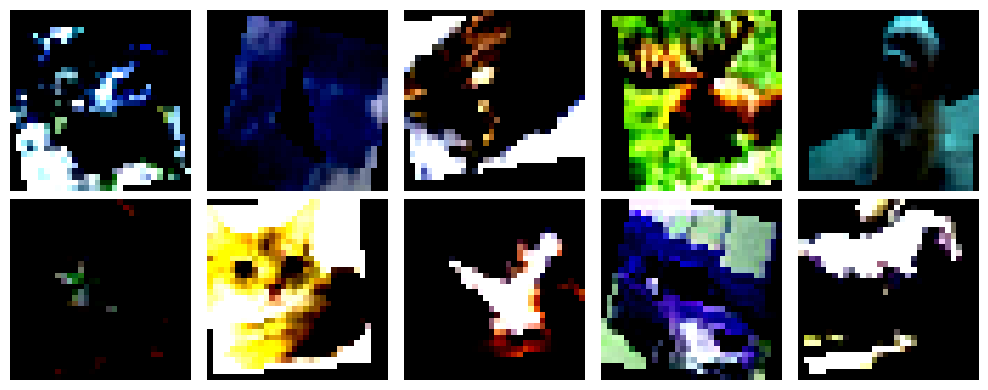

In [8]:
# Display first 10 images from training set
images, labels = next(iter(train_loader))

fig, ax = plt.subplots(2, 5, figsize=(10, 4))

for i in range(10):
    img = images[i].permute(1, 2, 0)  # Convert from CHW to HWC for display
    ax[i//5][i%5].imshow(img)
    ax[i//5][i%5].axis("off")

plt.tight_layout()
plt.show()

## Training and Evaluation Functions

Reusable functions for training any model and visualizing results.

In [14]:
def train_model(model, train_loader, val_loader, epochs=5, lr=0.001, weight_decay=1e-4, use_scheduler=True):
    """
    Train a model with tracking of loss and accuracy.
    Includes learning rate scheduling and weight decay for better performance.
    """
    model.to(device)

    criterion = torch.nn.CrossEntropyLoss()
    
    # Adam optimizer with L2 regularization
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Reduce learning rate when validation loss plateaus
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=2
        )

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        epoch_loss = 0
        preds = []
        targets = []

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            preds.extend(torch.argmax(out, 1).cpu().numpy())
            targets.extend(y.cpu().numpy())

        train_acc = accuracy_score(targets, preds)
        train_rec = recall_score(targets, preds, average="macro")
        avg_train_loss = epoch_loss / len(train_loader)

        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)

        # Validation phase
        model.eval()
        val_loss = 0
        val_preds = []
        val_targets = []

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)

                out = model(x)
                loss = criterion(out, y)
                val_loss += loss.item()

                val_preds.extend(torch.argmax(out, 1).cpu().numpy())
                val_targets.extend(y.cpu().numpy())

        val_acc = accuracy_score(val_targets, val_preds)
        val_rec = recall_score(val_targets, val_preds, average="macro")
        avg_val_loss = val_loss / len(val_loader)

        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)

        # Update learning rate based on validation loss
        if use_scheduler:
            scheduler.step(avg_val_loss)

        # Print progress
        print(f"Epoch: {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, Train Recall: {train_rec:.4f}")
        print(f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}, Val Recall: {val_rec:.4f}")
        print(f"Current LR: {optimizer.param_groups[0]['lr']:.6f}")
        print("-" * 60)

    return train_losses, val_losses, train_accs, val_accs

In [15]:
def plot_losses(train_losses, val_losses, title):
    """Plot training and validation losses over epochs."""
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', marker='o')
    plt.plot(val_losses, label='Val Loss', marker='s')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def plot_metrics(train_accs, val_accs, title):
    """Plot training and validation accuracy over epochs."""
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_accs, label='Train Accuracy', marker='o')
    plt.plot(val_accs, label='Val Accuracy', marker='s')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [16]:
def show_confusion(model, loader):
    """Display confusion matrix to see which classes are confused."""
    model.eval()
    preds = []
    targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            p = torch.argmax(out, 1).cpu().numpy()
            preds.extend(p)
            targets.extend(y.numpy())

    cm = confusion_matrix(targets, preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

## Model 1: Multi-Layer Perceptron (MLP)

Simple feedforward network with fully connected layers.
Good baseline but doesn't leverage spatial structure of images.

In [17]:
class MLP(nn.Module):
    """
    Multi-Layer Perceptron with BatchNorm and Dropout.
    Flattens the image and processes through fully connected layers.
    """
    def __init__(self, dropout_rate=0.5):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),  # 32x32x3 -> 3072
    
            # First hidden layer
            nn.Linear(3072, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Second hidden layer
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Third hidden layer
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.5),  # Less dropout near output

            # Output layer - 10 CIFAR-10 classes
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

### Train MLP Model

Epoch: 1/5
Train Loss: 2.1678, Train Acc: 0.1994, Train Recall: 0.1989
Val Loss: 1.9693, Val Acc: 0.2865, Val Recall: 0.2842
Current LR: 0.001000
------------------------------------------------------------
Epoch: 2/5
Train Loss: 2.0234, Train Acc: 0.2449, Train Recall: 0.2446
Val Loss: 1.8966, Val Acc: 0.3295, Val Recall: 0.3256
Current LR: 0.001000
------------------------------------------------------------
Epoch: 3/5
Train Loss: 1.9667, Train Acc: 0.2654, Train Recall: 0.2652
Val Loss: 1.8461, Val Acc: 0.3350, Val Recall: 0.3325
Current LR: 0.001000
------------------------------------------------------------
Epoch: 4/5
Train Loss: 1.9522, Train Acc: 0.2843, Train Recall: 0.2843
Val Loss: 1.8057, Val Acc: 0.3615, Val Recall: 0.3581
Current LR: 0.001000
------------------------------------------------------------
Epoch: 5/5
Train Loss: 1.9105, Train Acc: 0.3010, Train Recall: 0.3010
Val Loss: 1.8020, Val Acc: 0.3615, Val Recall: 0.3568
Current LR: 0.001000
--------------------------

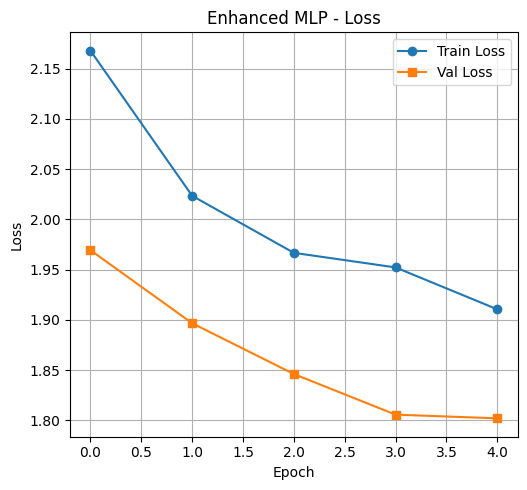

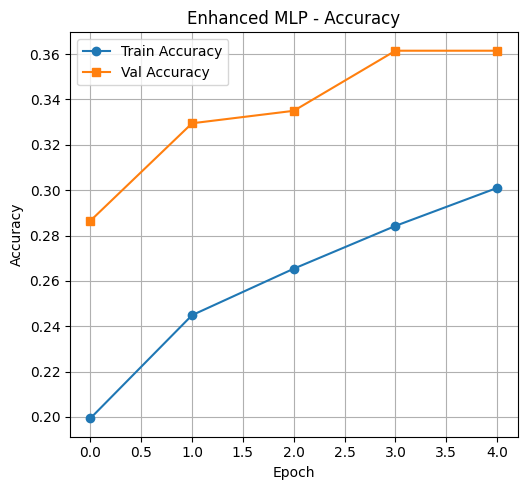

In [18]:
# Initialize and train MLP
mlp = MLP(dropout_rate=0.5)

mlp_train_losses, mlp_val_losses, mlp_train_accs, mlp_val_accs = train_model(
    mlp,
    train_loader,
    val_loader,
    epochs=5,          # Fast training with subset
    lr=0.001,
    weight_decay=1e-4
)

# Visualize results
plot_losses(mlp_train_losses, mlp_val_losses, "Enhanced MLP")
plot_metrics(mlp_train_accs, mlp_val_accs, "Enhanced MLP")

## Model 2: Convolutional Neural Network (CNN)

Custom CNN with 3 conv blocks using BatchNorm and Dropout.
Leverages spatial structure for better feature extraction.

In [19]:
class CNN(nn.Module):
    """
    Custom CNN with 3 convolutional blocks.
    Each block has 2 conv layers + BatchNorm + ReLU + MaxPool + Dropout.
    """
    def __init__(self, dropout_rate=0.5):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: 32x32 -> 16x16
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),

            # Block 2: 16x16 -> 8x8
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),

            # Block 3: 8x8 -> 4x4
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.4)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),  # 128*4*4 = 2048

            nn.Linear(128*4*4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.5),

            nn.Linear(256, 10)  # 10 classes
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [20]:
def show_random_filters(conv_layer, num_filters=16):

    filters = conv_layer.weight.data.cpu()

    total_filters = filters.shape[0]
    rand_ids = np.random.choice(total_filters, num_filters, replace=False)

    fig, ax = plt.subplots(4,4,figsize=(6,6))

    for i,idx in enumerate(rand_ids):

        f = filters[idx][0]

        ax[i//4][i%4].imshow(f, cmap="gray")
        ax[i//4][i%4].axis("off")

    plt.show()

### Train CNN Model

Filters BEFORE training


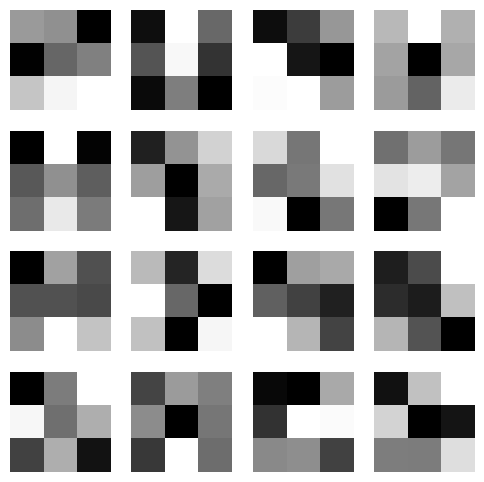

Epoch: 1/5
Train Loss: 2.0877, Train Acc: 0.2185, Train Recall: 0.2183
Val Loss: 1.7846, Val Acc: 0.3425, Val Recall: 0.3346
Current LR: 0.001000
------------------------------------------------------------
Epoch: 2/5
Train Loss: 1.8896, Train Acc: 0.2928, Train Recall: 0.2931
Val Loss: 1.7125, Val Acc: 0.3660, Val Recall: 0.3579
Current LR: 0.001000
------------------------------------------------------------
Epoch: 3/5
Train Loss: 1.8172, Train Acc: 0.3306, Train Recall: 0.3309
Val Loss: 1.5894, Val Acc: 0.4175, Val Recall: 0.4112
Current LR: 0.001000
------------------------------------------------------------
Epoch: 4/5
Train Loss: 1.7443, Train Acc: 0.3586, Train Recall: 0.3589
Val Loss: 1.4973, Val Acc: 0.4590, Val Recall: 0.4576
Current LR: 0.001000
------------------------------------------------------------
Epoch: 5/5
Train Loss: 1.6963, Train Acc: 0.3800, Train Recall: 0.3804
Val Loss: 1.4583, Val Acc: 0.4675, Val Recall: 0.4668
Current LR: 0.001000
--------------------------

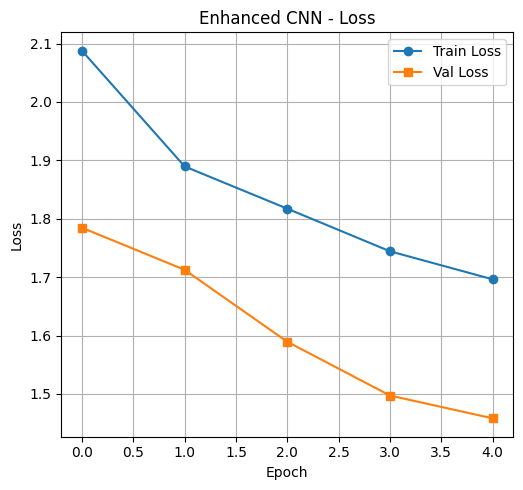

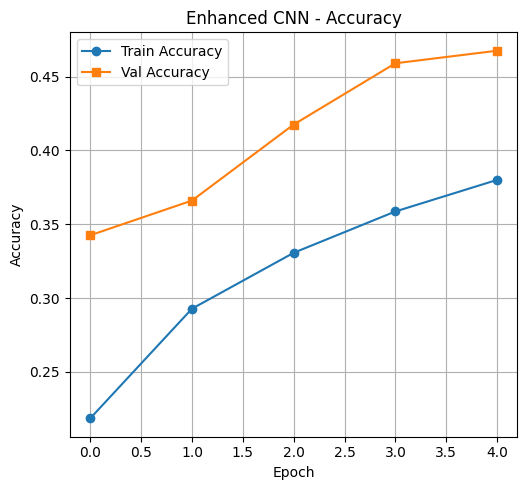

Filters AFTER training


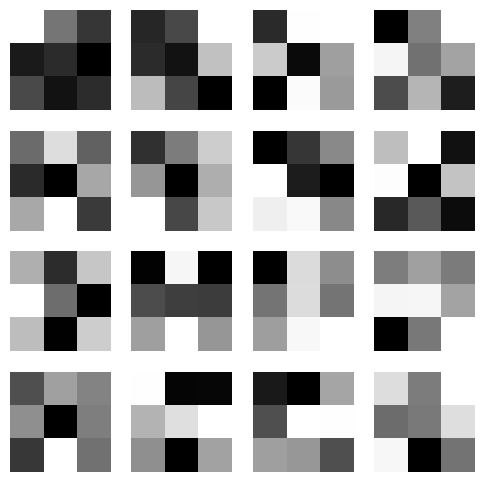

In [22]:
# Initialize and train CNN
print("Filters BEFORE training")

cnn = CNN(dropout_rate=0.5)

show_random_filters(cnn.features[0])

cnn_train_losses, cnn_val_losses, cnn_train_accs, cnn_val_accs = train_model(
    cnn,
    train_loader,
    val_loader,
    epochs=5,
    lr=0.001,
    weight_decay=1e-4
)

# Visualize results
plot_losses(cnn_train_losses, cnn_val_losses, "Enhanced CNN")
plot_metrics(cnn_train_accs, cnn_val_accs, "Enhanced CNN")

print("Filters AFTER training")

show_random_filters(cnn.features[0])

## Model 3: Transfer Learning with ResNet18

Using pretrained ResNet18 from ImageNet.
We'll try 3 approaches:
1. **Fine-tune only FC layer** - Fastest, freezes all conv layers
2. **Fine-tune last block + FC** - Balances speed and accuracy
3. **Fine-tune full model** - Slowest but potentially best

In [23]:
# Load pretrained ResNet18 from ImageNet
resnet = models.resnet18(pretrained=True)

# Replace final layer for CIFAR-10 (10 classes instead of 1000)
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 10)

print(f"ResNet FC layer changed: {num_features} -> 10 classes")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 228MB/s]

ResNet FC layer changed: 512 -> 10 classes


### Load Pretrained ResNet18

In [24]:
# Freeze all layers
for param in resnet.parameters():
    param.requires_grad = False

# Unfreeze only FC layer
for param in resnet.fc.parameters():
    param.requires_grad = True

print("Only FC layer is trainable")

Only FC layer is trainable


### Approach 1: Train Only FC Layer

Freeze all convolutional layers, train only the new FC layer.

Epoch: 1/5
Train Loss: 1.6289, Train Acc: 0.4622, Train Recall: 0.4616
Val Loss: 1.0768, Val Acc: 0.6550, Val Recall: 0.6563
Current LR: 0.001000
------------------------------------------------------------
Epoch: 2/5
Train Loss: 1.1072, Train Acc: 0.6516, Train Recall: 0.6521
Val Loss: 0.8453, Val Acc: 0.7255, Val Recall: 0.7264
Current LR: 0.001000
------------------------------------------------------------
Epoch: 3/5
Train Loss: 0.9781, Train Acc: 0.6759, Train Recall: 0.6763
Val Loss: 0.7472, Val Acc: 0.7565, Val Recall: 0.7555
Current LR: 0.001000
------------------------------------------------------------
Epoch: 4/5
Train Loss: 0.9243, Train Acc: 0.6891, Train Recall: 0.6896
Val Loss: 0.7332, Val Acc: 0.7595, Val Recall: 0.7596
Current LR: 0.001000
------------------------------------------------------------
Epoch: 5/5
Train Loss: 0.8935, Train Acc: 0.6989, Train Recall: 0.6993
Val Loss: 0.7052, Val Acc: 0.7555, Val Recall: 0.7540
Current LR: 0.001000
--------------------------

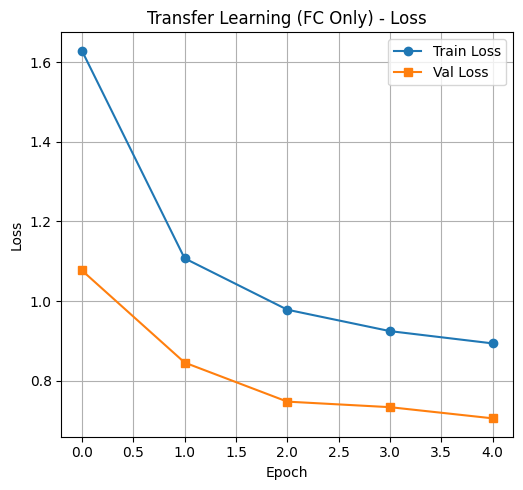

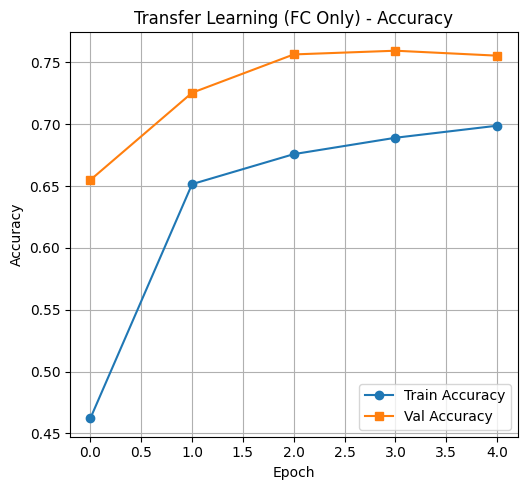

In [25]:
# Train with only FC layer unfrozen
resnet_fc_train_losses, resnet_fc_val_losses, resnet_fc_train_accs, resnet_fc_val_accs = train_model(
    resnet,
    train_loader_resnet,
    val_loader_resnet,
    epochs=5,
    lr=0.001,
    weight_decay=1e-4
)

plot_losses(resnet_fc_train_losses, resnet_fc_val_losses, "Transfer Learning (FC Only)")
plot_metrics(resnet_fc_train_accs, resnet_fc_val_accs, "Transfer Learning (FC Only)")

### Approach 2: Fine-tune Last Block + FC

Unfreeze layer4 (last conv block) and FC for better adaptation.

In [26]:
# Unfreeze last convolutional block (layer4)
for param in resnet.layer4.parameters():
    param.requires_grad = True

# FC layer already unfrozen from before
for param in resnet.fc.parameters():
    param.requires_grad = True

print("Layer4 and FC are trainable")

Layer4 and FC are trainable


Epoch: 1/5
Train Loss: 0.6924, Train Acc: 0.7649, Train Recall: 0.7652
Val Loss: 0.4284, Val Acc: 0.8615, Val Recall: 0.8579
Current LR: 0.000500
------------------------------------------------------------
Epoch: 2/5
Train Loss: 0.4184, Train Acc: 0.8570, Train Recall: 0.8572
Val Loss: 0.4120, Val Acc: 0.8530, Val Recall: 0.8508
Current LR: 0.000500
------------------------------------------------------------
Epoch: 3/5
Train Loss: 0.3231, Train Acc: 0.8844, Train Recall: 0.8844
Val Loss: 0.4412, Val Acc: 0.8565, Val Recall: 0.8526
Current LR: 0.000500
------------------------------------------------------------
Epoch: 4/5
Train Loss: 0.2876, Train Acc: 0.8992, Train Recall: 0.8992
Val Loss: 0.3629, Val Acc: 0.8835, Val Recall: 0.8821
Current LR: 0.000500
------------------------------------------------------------
Epoch: 5/5
Train Loss: 0.2345, Train Acc: 0.9206, Train Recall: 0.9206
Val Loss: 0.3843, Val Acc: 0.8805, Val Recall: 0.8787
Current LR: 0.000500
--------------------------

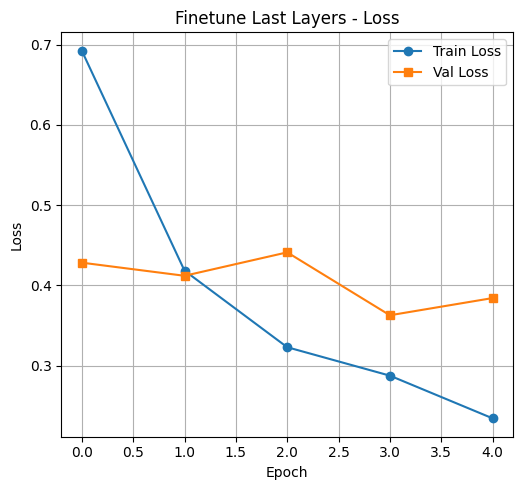

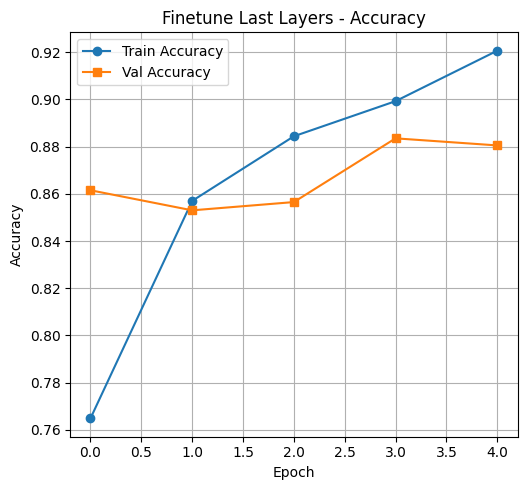

In [27]:
# Train with last block + FC unfrozen (lower learning rate)
resnet_last_train_losses, resnet_last_val_losses, resnet_last_train_accs, resnet_last_val_accs = train_model(
    resnet,
    train_loader_resnet,
    val_loader_resnet,
    epochs=5,
    lr=0.0005,  # Lower LR for fine-tuning
    weight_decay=1e-4
)

plot_losses(resnet_last_train_losses, resnet_last_val_losses, "Finetune Last Layers")
plot_metrics(resnet_last_train_accs, resnet_last_val_accs, "Finetune Last Layers")

### Approach 3: Fine-tune Full Model

Unfreeze all layers for complete adaptation (slowest).

In [28]:
# Unfreeze all layers
for param in resnet.parameters():
    param.requires_grad = True

print("All layers are trainable")

All layers are trainable


Epoch: 1/5
Train Loss: 0.1591, Train Acc: 0.9454, Train Recall: 0.9453
Val Loss: 0.3208, Val Acc: 0.8940, Val Recall: 0.8918
Current LR: 0.000100
------------------------------------------------------------
Epoch: 2/5
Train Loss: 0.1016, Train Acc: 0.9675, Train Recall: 0.9674
Val Loss: 0.2810, Val Acc: 0.9145, Val Recall: 0.9124
Current LR: 0.000100
------------------------------------------------------------
Epoch: 3/5
Train Loss: 0.0695, Train Acc: 0.9760, Train Recall: 0.9760
Val Loss: 0.2842, Val Acc: 0.9155, Val Recall: 0.9150
Current LR: 0.000100
------------------------------------------------------------
Epoch: 4/5
Train Loss: 0.0657, Train Acc: 0.9762, Train Recall: 0.9763
Val Loss: 0.3075, Val Acc: 0.9080, Val Recall: 0.9064
Current LR: 0.000100
------------------------------------------------------------
Epoch: 5/5
Train Loss: 0.0501, Train Acc: 0.9836, Train Recall: 0.9837
Val Loss: 0.3211, Val Acc: 0.9080, Val Recall: 0.9070
Current LR: 0.000050
--------------------------

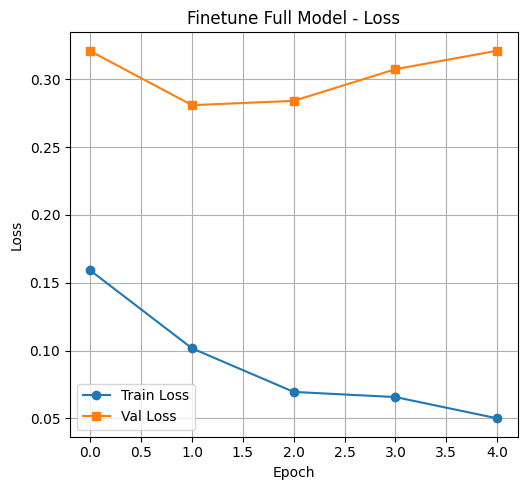

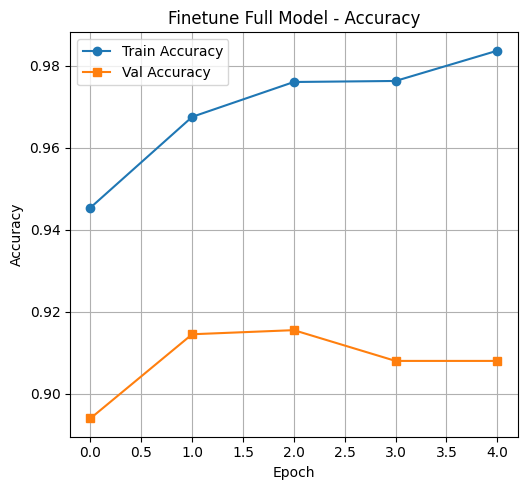

In [29]:
# Train full model (even lower learning rate)
resnet_full_train_losses, resnet_full_val_losses, resnet_full_train_accs, resnet_full_val_accs = train_model(
    resnet,
    train_loader_resnet,
    val_loader_resnet,
    epochs=5,
    lr=0.0001,  # Very low LR for full fine-tuning
    weight_decay=1e-4
)

plot_losses(resnet_full_train_losses, resnet_full_val_losses, "Finetune Full Model")
plot_metrics(resnet_full_train_accs, resnet_full_val_accs, "Finetune Full Model")

## Conclusion

### Models Compared:
1. **MLP (Multi-Layer Perceptron)**: Simple baseline using only fully connected layers
2. **CNN (Convolutional Neural Network)**: Custom architecture leveraging spatial features
3. **ResNet18 Transfer Learning**: Pretrained model with 3 fine-tuning strategies

### Key Findings:

**Expected Performance Hierarchy:**
- **ResNet with full fine-tuning** should achieve highest accuracy due to pretrained features + full adaptation
- **CNN** should outperform MLP by capturing spatial relationships in images
- **MLP** provides a baseline but struggles with spatial data

**Transfer Learning Strategies:**
- **FC Only**: Fastest training, good for quick prototyping
- **Last Block + FC**: Balanced approach, better domain adaptation
- **Full Model**: Most flexible, captures dataset-specific patterns

### Training Optimizations Used:
- **Data augmentation** (flips, crops, rotations) to prevent overfitting
- **Batch normalization** for stable training
- **Dropout** for regularization
- **Learning rate scheduling** to adapt during training
- **Weight decay (L2 regularization)** to prevent overfitting

### Notes:
- Trained on **20% subset** for fast experimentation
- For production: train on full dataset with more epochs
- ResNet requires larger images (224x224) vs CIFAR-10 native (32x32)

The subset training approach allows rapid iteration and model comparison before committing to full training runs.